# Barotropic instability of a zonal jet in a channel

A single-layer shallow-water experiment (`OSSWEM`) on a $\beta$-plane. The domain is a
zonal channel: **periodic in $x$**, with **solid walls north and south** (imposed as dry
rows, $D=0$). A balanced eastward jet is held against instability by a localized sponge,
while the interior of the channel is free to evolve.

## The problem

A zonal jet $\bar{u}(y)$ that is sharp enough develops a sign change in the meridional
gradient of background potential vorticity. By the **Rayleigh–Kuo / Charney–Stern**
criterion this is a *necessary* condition for barotropic instability. The jet here
satisfies it, so a small perturbation grows into meanders and eddies that fluxes momentum
and stir PV — the classic route by which a jet sheds eddies. The localized sponge keeps
re-supplying the unstable jet, so the channel reaches a statistically steady turbulent
state rather than mixing the jet away.

The instability is *barotropic* (drawing on the horizontal shear of the mean flow); with a
single layer there is no baroclinic (vertical-shear) energy source.

## Configuration

| Quantity | Value | Notes |
|---|---|---|
| Domain | $900 \times 600$ km | 50% longer in $x$ than $y$ |
| Resolution | $\Delta x = \Delta y = 10$ km | at the default `nj = 60` ($n_i = 90$) |
| Reduced gravity $g'$ | $0.08$ m $\text{s}^{-2}$ | gravity-wave speed $c_g=\sqrt{g'H}\approx 8$ m $s^{-1}$ |
| Layer thickness $H$ | $800$ m | |
| Coriolis $f_0$, $\beta$ | $10^{-4} \text{s}^{-1}$, $3\times 10^{-11}$ $\text{m}^{-1} \text{s}^{-1}$ | deformation radius $R_d=c_g/f_0\approx 80$ km |
| Bottom drag $\epsilon$ | $2.5\times10^{-5}$ m $\text{s}^{-1}$ | |
| Lateral viscosity $\nu_h$ | $200$ $\text{m}^2$ $\text{s}^{-1}$ | |

- **Jet target:** eastward, peak $1$ m $\text{s}^{-1}$, spanning $y/L_y \in [0.4, 0.6]$ (half-width
  $\sim 60$ km, comparable to $R_d$). Its free surface is set in geostrophic balance,
  $f\,u = -g'\,\partial_y\eta$, and used as the initial state everywhere.
- **Sponge (forcing):** restores $u\to$ jet, $v\to 0$, $h\to$ balanced at rate
  $10^{-5}$ $\text{s}^{-1}$ over the westernmost $150$ km plus the outer $100$ km near each wall.
  The $\beta$ term arrests the largest meridional mode. The restoring is applied with a
  backward-Euler step (unconditionally stable). The rest of the domain is unforced.
- **Seed:** a small smooth Gaussian bump in $h$ perturbs the balanced state to trigger the
  instability.

The `nj`/`run_params` line in the next cell selects the resolution and run length; coarser
settings run fast and still capture the instability, finer ones resolve more eddies.

In [1]:
import sys                         
import matplotlib.pyplot as plt
import numpy as np
import scipy

from OSSWEM_2D_orlanski import SSWEM
from OSSWEM_2D_orlanski import SSWEM as SSWEM_2D



# Configuration

The notebook supports different type of jet profiles 

- `JET_CONFIG` controls the shape of the zonal jet and `U_JET` controls the maximum speed in the jet. 
- `JET_HW` controls the width of the jet. 

## `PEAK_ON_GRID`
Controls what `U_JET` means.

The cubic bump reaches `U_JET` exactly at the jet centre, but the $u$-grid rows straddle
that centre rather than landing on it.

## External forcing

- `EXT_CONFIG` selects what the Orlanski inflow branch reads as the exterior solution at
  `b_obc`: `'climatology'` (frozen $t=0$ column), `'exact'` (the control run itself), or
  `'coarse'` (control run box-averaged, emulating a coarser outer model).
- `EXT_WIN` $=(n_t, n_y, n_x)$ is the averaging window for `'coarse'`; each entry must be odd.
  It also sets how many columns the control run's probe stores, via `_ext_probe_span`.

See the "External forcing at the open boundary" section below for details.


In [2]:
JET_CONFIG = '2jet'          
U_JET      = 1.4            
JET_HW     = 60.e3           # jet half-width [m]; keep < Ly/6 so twin jets don't overlap

PEAK_ON_GRID = False         

JET_CENTERS = {'1jet': (0.5,),          
               '2jet': (2/5, 3/5)}      

def _build_u_target(M, config=None, u_jet=None, hw=None, peak_on_grid=None):   
    """u_target for the requested jet configuration, scaled to peak speed u_jet."""
    config = JET_CONFIG         
    u_jet  = U_JET              
    hw     = JET_HW               
    pog    = PEAK_ON_GRID 
    yc   = M.yu / M.Ly                                        
    hwn  = hw / M.Ly                                        
    bump = lambda c: (SSWEM._cubint(yc, c - hwn, c)           
                      - SSWEM._cubint(yc, c, c + hwn))       
    profile = sum(bump(c) for c in JET_CENTERS[config])      
    profile = profile * (u_jet / profile.max() if pog else u_jet)   
    u_target = np.empty_like(M.u)                            
    for k in range(M.nk):                                    
        u_target[k, :] = profile                             
    return u_target                                          

print(f'[CFG] {JET_CONFIG}: {len(JET_CENTERS[JET_CONFIG])} jet(s), peak {U_JET} m/s, '
      f'half-width {JET_HW/1e3:.0f} km, peak_on_grid={PEAK_ON_GRID}')

# External Forcing settings
EXT_CONFIG = 'exact'         # 'climatology' | 'exact' | 'coarse'
EXT_WIN    = (5, 5, 5)       # (nt, ny, nx) box-average window for 'coarse', each number must be odd. 

def _ext_probe_span(b_obc):                                  
    """(probe_i0, n_probe) covering BOTH the [b-2, b_obc] diagnostics stencil and the
    coarse x-window b_obc +/- nx//2.  Feed straight into run_record_bc."""
    half = (EXT_WIN[2] // 2) if EXT_CONFIG == 'coarse' else 0    
    i0   = min(b_obc - 2, b_obc - half)                          
    i1   = max(b_obc,     b_obc + half)                          
    return int(i0), int(i1 - i0 + 1)                             

def _build_ext_forcing(probe, ic, b_obc, M, config=None, win=None):   
    """(h_ext_all, u_ext_all, v_ext_all), each (nstep, nk, nj), for the east OBC.

    climatology - frozen t=0 column at b_obc (no time information at all).
    exact       - the control run's own column at b_obc (perfect exterior).
    coarse      - control run block-averaged over an (nt, ny, nx) box centred on
                  (t, j, b_obc): emulates forcing from a coarser-resolution model.
    """
    from scipy.ndimage import uniform_filter1d                   
    config = EXT_CONFIG if config is None else config            
    win    = EXT_WIN    if win    is None else win               
    cols   = [int(c) for c in probe['cols']]                     
    if b_obc not in cols:                                        
        raise ValueError(f'probe does not cover b_obc={b_obc}; probe cols = {cols}')
    ib    = cols.index(b_obc)                                     #b_obc's slot in the probe
    nstep = probe['h'].shape[0]                                  

    out = {}                                                     
    if config == 'climatology':                                  
        for name, a0 in (('h', ic[2]), ('u', ic[0]), ('v', ic[1])):
            out[name] = np.broadcast_to(a0[:, :, b_obc], (nstep, M.nk, M.nj)).copy()
    elif config == 'exact':                                      
        for name in ('h', 'u', 'v'):
            out[name] = probe[name][:, :, :, ib].copy()
    elif config == 'coarse':                                     
        nt, ny, nx = (int(w) for w in win)                       
        for lbl, w in (('nt', nt), ('ny', ny), ('nx', nx)):      
            if w < 1 or w % 2 == 0:
                raise ValueError(f'EXT_WIN {lbl} must be a positive ODD integer, got {w}')
        if ib - nx // 2 < 0 or ib + nx // 2 > len(cols) - 1:      #else the x-average silently clamps
            raise ValueError(f'probe cols {cols} too narrow for nx={nx} centred on b_obc={b_obc}; '
                             f're-run the control cell with probe_i0, n_probe = _ext_probe_span(b_obc)')
        for name in ('h', 'u', 'v'):                              #one field at a time (probe is large)
            A = np.asarray(probe[name], dtype=float)              #(nstep, nk, nj, ncol)
            if nt > 1: A = uniform_filter1d(A, nt, axis=0, mode='nearest')    #time
            if ny > 1: A = uniform_filter1d(A, ny, axis=2, mode='nearest')    #along-boundary y (walls -> edge clamp)
            if nx > 1: A = uniform_filter1d(A, nx, axis=3, mode='nearest')    #cross-boundary x
            out[name] = A[:, :, :, ib].copy()                    
            del A                                                 #free the filtered copy before the next field
    else:                                                        
        raise ValueError(f"EXT_CONFIG must be 'climatology' | 'exact' | 'coarse', got {config!r}")
    return out['h'], out['u'], out['v']                          

print(f'[EXT] {EXT_CONFIG}' + (f', window (nt,ny,nx) = {tuple(EXT_WIN)}' if EXT_CONFIG == 'coarse' else ''))


# Which orlanski run to do
RUN_1D = True                # also run the 1D Orlanski (r_y = 0) for comparison
RUN_2D = True                # run the full 2D Orlanski



[CFG] 2jet: 2 jet(s), peak 1.4 m/s, half-width 60 km, peak_on_grid=False
[EXT] exact


In [3]:
# nj, ru_params = [dt, steps/segment, segments]
# nj, run_params = 40, [200., 500, 25]  # Barely permitted eddies
nj, run_params = 180, [200., 1, 10]  # Coarsest resolution with good instabilities  # [2JET] 150 segs to match NN
# nj, run_params = 120, [50., 2000, 100]  # Finer resolution
# nj, run_params = 180, [5., 5000, 100]  # Finer resolution is very unstable

# Resolution and Length Setting
dx = 10.e3 # Spatial resolution (dx = dy)
Lx = 2500.e3 # Domain length

M = SSWEM(int(Lx / dx),
          0.08,    # Gravity [m s-2]
          800.,    # Nominal layer thickness [m]
          Lx,  # Domain width [m]  (50% longer in x than y)
          1e-4,   # Coriolis [s-1]
          0, # df/dy [m-1 s-1]  (beta-plane arrests the large-scale meridional mode) used to be 3.0e-11
          2.5e-5,  # Bottom drag rate [m s-1]
          2e2,     # Lateral viscosity [m2 s-1]
          nj=nj,    # Rectangular channel
          )
# M.D[0,:] = 0       # dry rows N/S -> zonal channel walls
# M.D[-1,:] = 0

M.u_target = _build_u_target(M)

uy  = M.u_target[0].mean(axis=1)                   # u(y)
f_h = M.fo + M.beta * M.yh1                        # f(y) at row centres
eta = -(1.0/M.g[0]) * np.cumsum(f_h * uy) * M.dy
eta -= eta.mean() # Why remove mean? 
hbal = np.maximum(M.D + eta[:, None], 0.0)         # balanced thickness
hbal[0, :] = hbal[1, 1]
hbal[-1, :] = hbal[-2, 1]

# ============================= Sponge Layer Setup ==============================================

# Sponges restoring u->jet, v->0, h->balanced: a western sponge over the westernmost
# 150 km, plus N/S near-wall sponges over the outer 100 km.
# Local forcing only; the rest of the domain is free to evolve.
factor = 1.5
def ramp(x, x0, Lx, p=2): return np.clip((x - x0)/(Lx - x0), 0, 1)**p
def ramp2(x, x0, Lx, factor=1.5): return np.clip(factor*(x - x0)/(Lx - x0), 0, 1)**2
rate_h, rate_uv, Lw_uv, Lw_h, yb = 1.e-5, 1.e-5, 150.e3, 150.e3, 250e3

M.u_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xu, 0., Lw_uv) * (M.xu < Lw_uv), ramp(M.yu, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) )
M.v_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xv, 0., Lw_uv) * (M.xv < Lw_uv), ramp(M.yv, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) )
M.h_relax  = rate_h * np.maximum( np.maximum( ramp2(M.xh, 0., Lw_uv) * (M.xh < Lw_uv), ramp(M.yh, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) )
M.h_target = hbal[None, :, :].copy()               # u_target/v_target already set (jet / 0)

#====================================== END ======================================================

mesh: ni = 250  nj = 180
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 31.25
Res: Ld/dx = 8.0


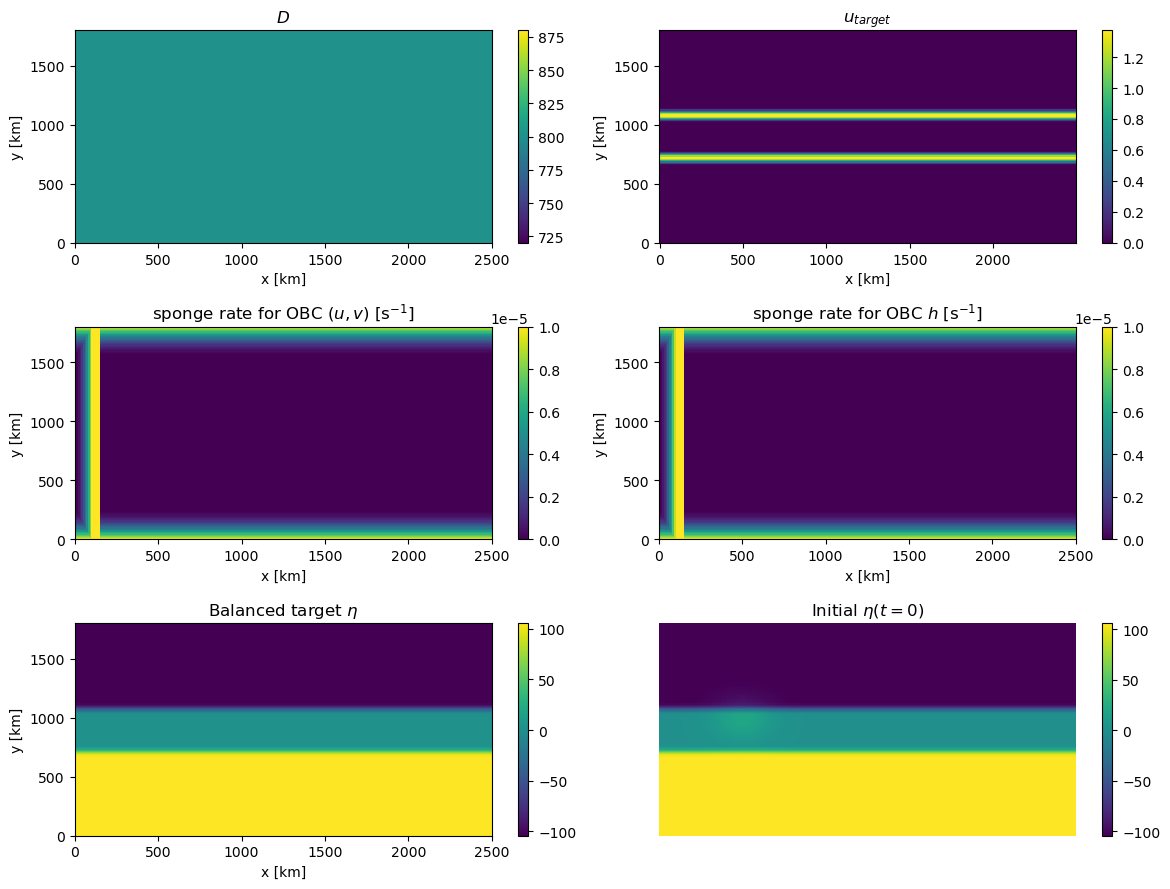

In [4]:
# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[0] = M.u_target[0].copy()
M.h[0] = hbal.copy()
M.perturb_h(20., 0.05 * M.Lx, 5.e5, 0.55 * M.Ly)

# Setup diagnostics
fig, ax = plt.subplots(3, 2, figsize=(12, 9))
cs = ax[0,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.D ); fig.colorbar(cs, ax=ax[0,0]); ax[0,0].set_title(r'$D$');
cs = ax[0,1].pcolormesh( M.xq1/1e3, M.yh1/1e3, M.u_target[0] ); fig.colorbar(cs, ax=ax[0,1]); ax[0,1].set_title(r'$u_{target}$');
cs = ax[1,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.u_relax[0] ); fig.colorbar(cs, ax=ax[1,0]); ax[1,0].set_title('sponge rate for OBC ($u,v$) [$\\text{s}^{-1}$]');
cs = ax[1,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.h_relax[0] ); fig.colorbar(cs, ax=ax[1,1]); ax[1,1].set_title('sponge rate for OBC $h$ [$\\text{s}^{-1}$]');
cs = ax[2,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, hbal - M.D ); fig.colorbar(cs, ax=ax[2,0]); ax[2,0].set_title(r'Balanced target $\eta$');
cs = ax[2,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=ax[2,1]); ax[2,1].set_title(r'Initial $\eta(t=0)$');
ax[2,1].axis('off')                                # no sixth panel
for a in (ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]):
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout()

## Prescribed Western Boundary

The implementation of an open boundary condition effectively truncates the computational domain. To prevent numerical disturbances generated at the open boundary from propagating westward and re-entering the domain through the periodic boundary condition, the entire western sponge layer from the control simulation is stored at every time step and prescribed as the western boundary condition in the OBC simulations.

In [5]:
assert Lw_uv == Lw_h, "The Sponge Layer width of u,v is different from h"
n_bc = int(Lw_uv / dx)           # Number of stored columns                                       
i_edge  = np.where(M.xh1 < Lw_uv)[0].max()               
west_cols = np.arange(i_edge - n_bc + 1, i_edge + 1)            
print(f'[OBC] {n_bc} boundary columns i = {list(west_cols)},'
)

# Initial conditions of the field
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)  

[OBC] 15 boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)],


Rayleigh-Kuo (beta - U_yy) changes sign in interior: True


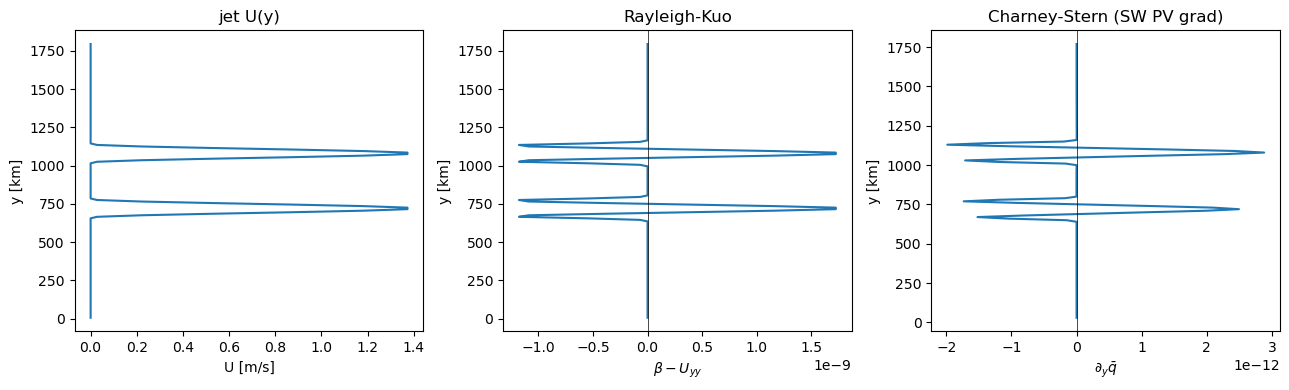

In [6]:
# Barotropic-instability criterion (Rayleigh-Kuo / Charney-Stern): a NECESSARY
# condition for instability is that the background potential-vorticity gradient
# changes sign in the interior. Evaluated on the initial balanced jet.
# See https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Kuo_criterion

U   = M.u[0].mean(axis=1)                          # U(y)
Uyy = np.gradient(np.gradient(U, M.yh1), M.yh1)
RK  = M.beta - Uyy                                 # Rayleigh-Kuo (non-divergent barotropic)
dqdy = np.gradient(M.q(k=0).mean(axis=1), M.yq1)   # Charney-Stern: d/dy of zonal-mean SW PV
dqdy[:3] = np.nan                                  # mask near-wall rows where h->0 makes
dqdy[-2:] = np.nan                                 # q=(f+zeta)/h spike and swamp the interior

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(U, M.yh1/1e3);    ax[0].set_xlabel('U [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('jet U(y)')
ax[1].plot(RK, M.yh1/1e3);   ax[1].axvline(0, color='k', lw=0.5); ax[1].set_xlabel(r'$\beta - U_{yy}$'); ax[1].set_ylabel('y [km]'); ax[1].set_title('Rayleigh-Kuo')
ax[2].plot(dqdy, M.yq1/1e3); ax[2].axvline(0, color='k', lw=0.5); ax[2].set_xlabel(r'$\partial_y \bar{q}$'); ax[2].set_ylabel('y [km]'); ax[2].set_title('Charney-Stern (SW PV grad)')
fig.tight_layout()
# With the near-wall spike masked, the interior sign change in the SW PV gradient is
# visible in the Charney-Stern panel; the Rayleigh-Kuo panel is the cleaner read.

jj = (M.yh1/M.Ly > 0.12) & (M.yh1/M.Ly < 0.88)     # interior (skip dry walls)
print('Rayleigh-Kuo (beta - U_yy) changes sign in interior:', bool((RK[jj].min() < 0) and (RK[jj].max() > 0)))

## Configuration of Open Boundary

Change `b_obc` to adjust the location of the open boundary. This number is non-dimensionaled, it is the index of the column of the open boundary. 

The flag `Store_downstream` controls storing every step for a contiguous block of columns near the east open boundary for the external forcing and further analysis of the phase velocity

The flag `Store_centerline` controls storing the center line of the domain, used for plotting Hovmoller diagram along center line. 

Depending on different type of external forcing setting, the columns to store are different, it is determined by `_probe_i0` and `_n_probe`. 

In [7]:
b_obc = 150                # Eastern open boundary location
ext_cols = np.array([b_obc + 1, b_obc + 2])    
pres_cols = west_cols
_probe_i0, _n_probe = _ext_probe_span(b_obc)   # [EXT] wide enough for the coarse x-window

Store_downstream = True
Store_centerline = True


In [8]:
u, v, h, time, h_bc_all, u_bc_all, v_bc_all, probe = M.run_record_bc(
    *run_params, pres_cols,
    store_downstream=Store_downstream, probe_i0=_probe_i0, n_probe=_n_probe)  


numba threads = 16
CFL: dt*f = 0.02
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 10
Time: Trun * fo = 0.2
Time: Trun * ( cg / L ) = 0.0064
[OBC] recording (u,v,h) at boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
[OBC] also storing downstream probe at columns i = 148..150
Running (record)...
...done


## External forcing at the open boundary

The Orlanski condition needs an *exterior* solution at column `b_obc` on inflow rows.
`EXT_CONFIG` (configuration cell) selects different type of external forcing


In [9]:
h_ext_all, u_ext_all, v_ext_all = _build_ext_forcing(probe, ic, b_obc, M)

_ib   = [int(c) for c in probe['cols']].index(b_obc)
_frac = h_ext_all.std(axis=0).mean() / max(probe['h'][:, :, :, _ib].std(axis=0).mean(), 1e-30)


In [10]:
# Plot the animation of the Control run. 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
# Compute PV for all time levels
pv = np.array([M.q(h=h[n], u=u[n], v=v[n], k=0) for n in range(len(time))])
# pv[:,:3,:] = 1e-7
# pv[:,-2:,:] = 1e-7

# Use consistent color limits across frames
vmin, vmax = pv.min(), pv.max()
cf = ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[-1], levels=100, vmin=vmin, vmax=vmax)
cb = fig.colorbar(cf)
ax.axvline(150, color='k', ls=':', lw=1)              # sponge edge: free model is east of x=150 km
ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
title = ax.set_title(f'$q$ at t = {time[0]/86400:.2f} days')

def update(n):
    ax.clear()
    ax.contourf(M.xq1/1e3, M.yq1/1e3, pv[n], levels=100, vmin=vmin, vmax=vmax)
    ax.axvline((Lw_uv)/1e3, color='k', ls=':', lw=1)          # sponge edge (ax.clear wipes it)
    ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')  # restore labels (ax.clear wipes them)
    ax.set_title(f'$q$ at t = {time[n]/86400:.2f} days')

anim = FuncAnimation(fig, update, frames=len(time), interval=100)
anim.save('pv_evolution.gif', writer='pillow', fps=10, dpi=100)   # save GIF (no ffmpeg needed)
plt.close(fig)
HTML(anim.to_jshtml())

# Original Run with Prescribed West Boundary + Orlanski East Boundary

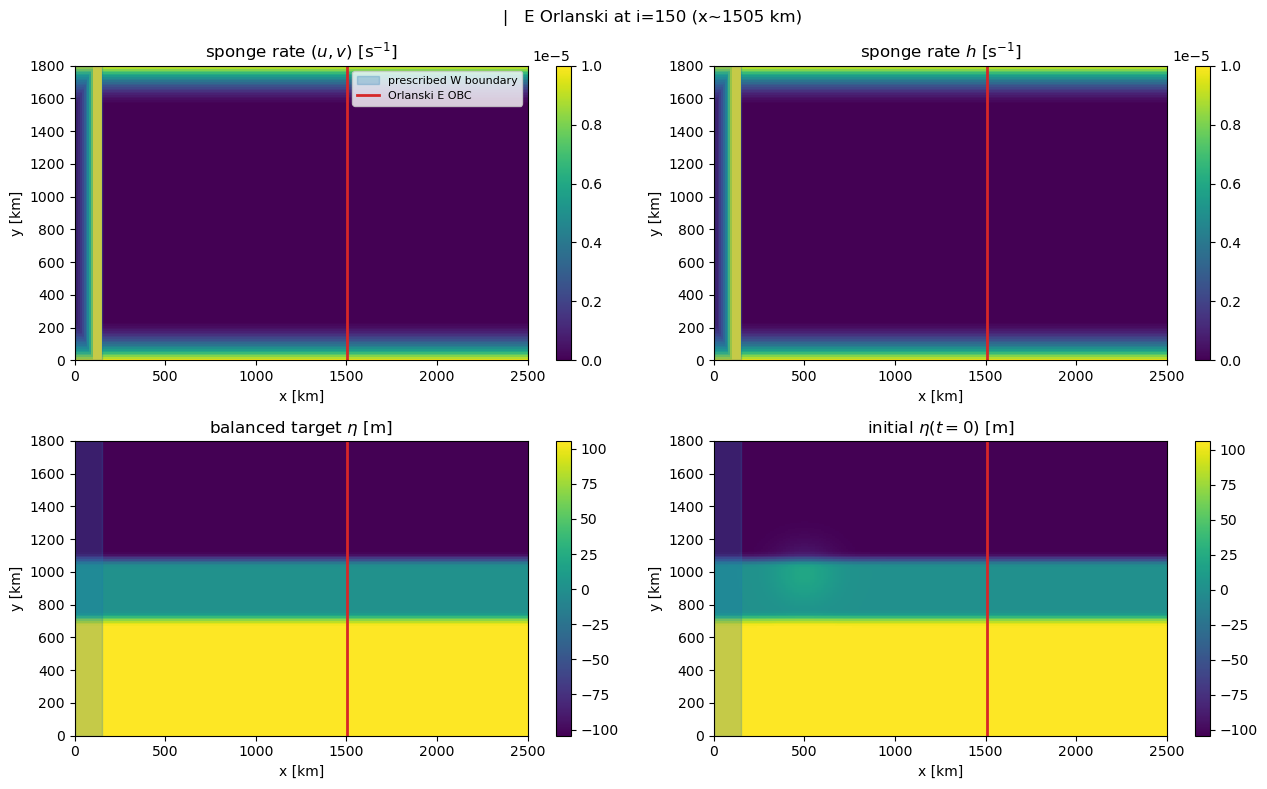

In [11]:
# b_obc = M.ni - 1 - 20                          # [OBC - Orlanski] eastern OBC column (also set in the run cell)
x_km  = M.xh1 / 1e3
y_km  = M.yh1 / 1e3
dx_km = M.dx / 1e3
eta_init = ic[2][0] - M.D                 # initial eta from the IC snapshot
eta_targ = M.h_target[0] - M.D            # balanced target eta
xW0 = x_km[west_cols.min()] - dx_km / 2     # prescribed-W band edges [km]
xW1 = x_km[west_cols.max()] + dx_km / 2
xE  = x_km[b_obc]                         # Orlanski-E column [km]

def _mark(ax):
    ax.axvspan(xW0, xW1, color='tab:blue', alpha=0.25, label='prescribed W boundary')
    ax.axvline(xE, color='tab:red', lw=2, label='Orlanski E OBC')

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
p = ax[0,0].pcolormesh(x_km, y_km, M.u_relax[0]); fig.colorbar(p, ax=ax[0,0]); ax[0,0].set_title(r'sponge rate $(u,v)$ [s$^{-1}$]')
p = ax[0,1].pcolormesh(x_km, y_km, M.h_relax[0]); fig.colorbar(p, ax=ax[0,1]); ax[0,1].set_title(r'sponge rate $h$ [s$^{-1}$]')
p = ax[1,0].pcolormesh(x_km, y_km, eta_targ);     fig.colorbar(p, ax=ax[1,0]); ax[1,0].set_title(r'balanced target $\eta$ [m]')
p = ax[1,1].pcolormesh(x_km, y_km, eta_init);     fig.colorbar(p, ax=ax[1,1]); ax[1,1].set_title(r'initial $\eta(t{=}0)$ [m]')
for a in ax.ravel():
    _mark(a); a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
ax[0,0].legend(loc='upper right', fontsize=8)
fig.suptitle(f'   |   E Orlanski at i={b_obc} (x~{xE:.0f} km)')
fig.tight_layout()

In [13]:
# Inflow nudging coefficient (fixed; used by the Orlanski update on inflow rows)
# In the note, it is recommended that \tau_in \sim days and here alpha_in = dt / \alpha_in so it is actually really small
tau_in = 2 # In days
ALPHA_IN = 200 / (tau_in * 86400)
# ALPHA_IN = 0.0   # [2JET] disabled: keep nonzero inflow nudging to match NN
print(ALPHA_IN)

0.0011574074074074073


In [14]:
# Run the 1D orlanski run
if RUN_1D:
    M1 = SSWEM_2D(M.ni, M.g, M.Ho, M.Lx, M.fo, M.beta, M.epsilon, M.nu_h,    
                  nu_v=M.nu_v, h_zonal_relax=M.h_zonal_relax, hsub=M.hsub,  
                  nj=M.nj, Ly=M.Ly)                                         
    M1.u_target = M.u_target.copy(); M1.v_target = M.v_target.copy(); M1.h_target = M.h_target.copy()
    M1.D[:] = M.D
    M1.u_relax = M.u_relax.copy(); M1.v_relax = M.v_relax.copy(); M1.h_relax = M.h_relax.copy()
    M1.u[:], M1.v[:], M1.h[:] = ic[0], ic[1], ic[2]                         
    M1.time, M1.iter = ic[3], ic[4]

    u3, v3, h3, time3, diff3, rx_1d = M1.run_obc(
        *run_params, pres_cols, h_bc_all, u_bc_all, v_bc_all, b_obc,
        nudging=True,
        h_ext_all=h_ext_all, u_ext_all=u_ext_all, v_ext_all=v_ext_all, alpha_in=ALPHA_IN,
        inflow_persistent=False,
        ry_2d=False)                                                         
else:
    u3 = v3 = h3 = time3 = rx_1d = None                                     


mesh: ni = 250  nj = 180
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 31.25
Res: Ld/dx = 8.0
numba threads = 16
CFL: dt*f = 0.02
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 10
Time: Trun * fo = 0.2
Time: Trun * ( cg / L ) = 0.0064
[OBC - Orlanski - 2D - IndepRx] east r_x estimated independently per field (h, u, v)
[RY1D] east OBC scheme: 1D Orlanski (r_y = 0)
[OBC - Orlanski - 2D - Nuding] east inflow scheme: NUDGING (alpha_in=0.00116, ghost wall removed)
...done
Mean r_x over run is h = -0.062u=0.000  v=-0.000


# 2D Numerical Open boundary condition run. 

## Inflow treatment
When the numerical scheme detects an inflow, the radiation alone cannot determin the solution. 

- `nudging` a flag. When `False`, the boundary is prescribed to the exterior forcing. 
- `alpha_in`, determines the nudging strength. Only read when `nudging = true`
- `inflow_persistent`, when `True`, clamp to $r_x \geq 0$, and the exterior data is ignored entirely, the boundary is updated using the value from previous step. 

## Boundary scheme
- `ry_2d` : `True`, full 2D orlanski open boundary condition. `False`, reduce to 1D orlanski scheme by setting $r_y = 0$. 
- `h_bc` : either `radiate` or `zerograd`, in the original paper, it is suggested that the surface sea height update law should follow 'zero-gradiant' which copies the interior neighbour. (This flag is set by default to `radiate` and can be changed in the module)

In [15]:
# 2D orlanksi run
M2 = SSWEM_2D(M.ni, M.g, M.Ho, M.Lx, M.fo, M.beta, M.epsilon, M.nu_h,   
              nu_v=M.nu_v, h_zonal_relax=M.h_zonal_relax, hsub=M.hsub, 
              nj=M.nj, Ly=M.Ly)                                        
# copy the configured sponge + targets from the 1D model M (set up above)
M2.u_target = M.u_target.copy(); M2.v_target = M.v_target.copy(); M2.h_target = M.h_target.copy()  
M2.D[:] = M.D                                                    
M2.u_relax  = M.u_relax.copy();  M2.v_relax  = M.v_relax.copy();  M2.h_relax = M.h_relax.copy()

# same initial condition
M2.u[:], M2.v[:], M2.h[:] = ic[0], ic[1], ic[2]
M2.time, M2.iter = ic[3], ic[4]

u3_2d, v3_2d, h3_2d, time3_2d, diff3_2d, rx_2d = M2.run_obc(
    *run_params, pres_cols, h_bc_all, u_bc_all, v_bc_all, b_obc,
    nudging=True,                                      
    h_ext_all=h_ext_all, u_ext_all=u_ext_all, v_ext_all=v_ext_all, alpha_in = ALPHA_IN,
    inflow_persistent=False,   
    ry_2d=True)                


mesh: ni = 250  nj = 180
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 31.25
Res: Ld/dx = 8.0
numba threads = 16
CFL: dt*f = 0.02
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 10
Time: Trun * fo = 0.2
Time: Trun * ( cg / L ) = 0.0064
[OBC - Orlanski - 2D - IndepRx] east r_x estimated independently per field (h, u, v)
[RY1D] east OBC scheme: 2D Orlanski (r_y active)
[OBC - Orlanski - 2D - Nuding] east inflow scheme: NUDGING (alpha_in=0.00116, ghost wall removed)
...done
Mean r_x over run is h = 0.000u=0.000  v=-0.000


## Potential vorticity: control vs Orlanski runs



In [16]:
# Animation
import matplotlib as mpl
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
from pathlib import Path

mpl.rcParams['animation.embed_limit'] = 200.0

K_LAYER, MAX_FRAMES, FPS, DPI = 0, 150, 8, 90
SAVE_GIF = True

bx   = int(b_obc)
jcut = slice(2, -2)                                   # drop the N/S wall rows

# ---- collect the runs that exist (control is always first) -------------------------
runs = [('control (truth)', h, u, v, time)]          
if RUN_1D and h3     is not None: runs.append(('1D Orlanski ($r_y=0$)', h3,    u3,    v3,    time3))
if RUN_2D and h3_2d  is not None: runs.append(('2D Orlanski',           h3_2d, u3_2d, v3_2d, time3_2d))

nfr    = min(len(r[4]) for r in runs)                  # common frame count
STRIDE = max(1, int(np.ceil(nfr / MAX_FRAMES)))
flist  = list(range(0, nfr, STRIDE))

def _pv_frames(hh, uu, vv):                           
    return np.array([M.q(h=hh[n], u=uu[n], v=vv[n], k=K_LAYER)[jcut, :bx + 1] for n in flist])

fields = [(lbl, _pv_frames(hh, uu, vv)) for lbl, hh, uu, vv, _ in runs]

vmin, vmax = float(fields[0][1].min()), float(fields[0][1].max())   # control sets the shared scale
xkm    = M.xq1[:bx + 1] / 1e3
ykm    = M.yq1[jcut] / 1e3
extent = [xkm.min(), xkm.max(), ykm.min(), ykm.max()]
tdays  = np.asarray(runs[0][4])[:nfr] / 86400.0

npanel = len(fields)
fig, axs = plt.subplots(1, npanel, figsize=(5 * npanel, 5), constrained_layout=True)
axs = np.atleast_1d(axs)
ims = []
for ax, (lbl, fld) in zip(axs, fields):
    im = ax.imshow(fld[0], origin='lower', extent=extent, cmap=plt.get_cmap('viridis', 100),
                   vmin=vmin, vmax=vmax, aspect='auto', interpolation='nearest')
    ax.axvline(xkm[-1], color='k', ls='--', lw=1.2)    # the open boundary
    ax.set(title=lbl, xlabel='x [km]', ylabel='y [km]')
    ims.append(im)
fig.colorbar(ims[0], ax=axs, shrink=0.85, label=r'$q=(f+v_x-u_y)/h$  [s$^{-1}$m$^{-1}$]')
suptitle = fig.suptitle('')

def _update(i):
    for im, (_, fld) in zip(ims, fields):
        im.set_data(fld[i])
    suptitle.set_text(f'potential vorticity $q$  |  t = {tdays[flist[i]]:.1f} days  '
                      f'(b_obc={bx}, dashed)')
    return ims

anim = FuncAnimation(fig, _update, frames=len(flist), interval=150, blit=False)
plt.close(fig)

if SAVE_GIF:
    out = Path('animations'); out.mkdir(exist_ok=True)
    gif = out / f'pv_compare_{npanel}panel.gif'
    anim.save(str(gif), writer=PillowWriter(fps=FPS), dpi=DPI)
    print(f'[PVCMP] {len(flist)} frames, stride={STRIDE} -> {gif}')

HTML(anim.to_jshtml())


[PVCMP] 11 frames, stride=1 -> animations\pv_compare_3panel.gif


1D Orlanski ($r_y=0$)    final = 1.1197e-10,  time-mean = 5.7920e-11  [s^-1 m^-1]
2D Orlanski              final = 1.0927e-10,  time-mean = 5.6943e-11  [s^-1 m^-1]


Text(0.5, 0.98, 'PV error on the interior box  (rows 25-154, cols 15-150)')

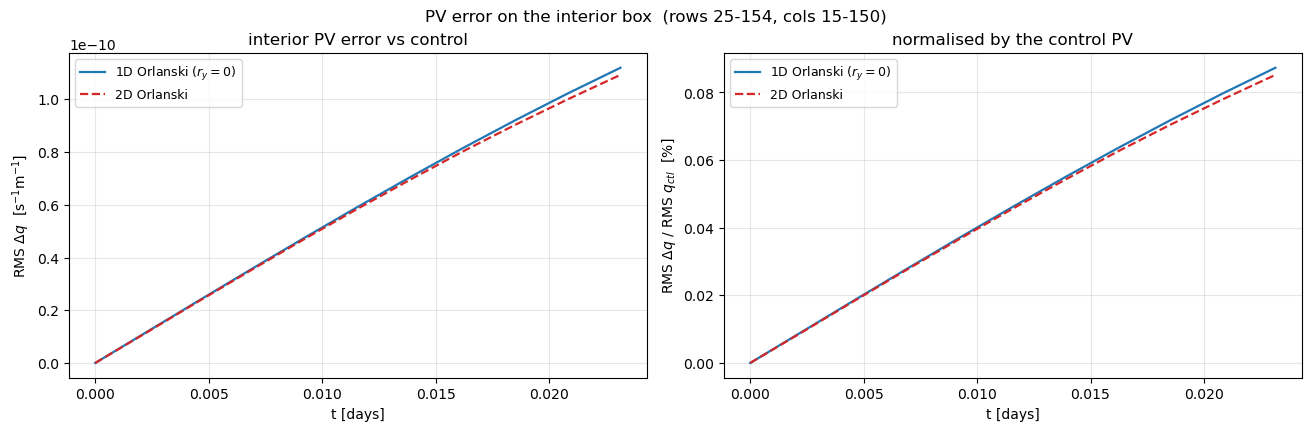

In [18]:
# Plot the rms error of the potential vorticity field. 
K_LAYER = 0

sponge_row = M.h_relax[K_LAYER, :, int(b_obc)] > 0     # rows inside the N/S sponge
_int_j = np.where(~sponge_row)[0]
jj = slice(int(_int_j.min()), int(_int_j.max()) + 1)    # interior rows
ii = slice(int(west_cols.max()) + 1, int(b_obc) + 1)    # interior cols: west band+1 .. b_obc

schemes = []                                        
if RUN_1D and h3    is not None: schemes.append(('1D Orlanski ($r_y=0$)', h3,    u3,    v3,    time3,    'C0', '-'))
if RUN_2D and h3_2d is not None: schemes.append(('2D Orlanski',           h3_2d, u3_2d, v3_2d, time3_2d, 'C3', '--'))


nfr = min([len(time)] + [len(s[4]) for s in schemes])

def _pv(hh, uu, vv, n):                                 
    return M.q(h=hh[n], u=uu[n], v=vv[n], k=K_LAYER)[jj, ii]

q_ctl = np.array([_pv(h, u, v, n) for n in range(nfr)])          # control PV
q_rms = np.sqrt((q_ctl ** 2).mean(axis=(1, 2)))                  # for the normalised curve
t_days = time[:nfr] / 86400.0

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)
for lbl, hh, uu, vv, _t, color, ls in schemes:
    err = np.array([_pv(hh, uu, vv, n) - q_ctl[n] for n in range(nfr)])
    rms = np.sqrt((err ** 2).mean(axis=(1, 2)))
    ax[0].plot(t_days, rms, color=color, ls=ls, lw=1.6, label=lbl)
    ax[1].plot(t_days, 100 * rms / np.maximum(q_rms, 1e-30), color=color, ls=ls, lw=1.6, label=lbl)
    print(f'{lbl:24s} final = {rms[-1]:.4e},  time-mean = {rms.mean():.4e}  [s^-1 m^-1]')

ax[0].set(xlabel='t [days]', ylabel=r'RMS $\Delta q$  [s$^{-1}$m$^{-1}$]',
          title='interior PV error vs control')
ax[1].set(xlabel='t [days]', ylabel=r'RMS $\Delta q$ / RMS $q_{ctl}$  [%]',
          title='normalised by the control PV')
for a in ax:
    a.grid(alpha=0.3); a.legend(fontsize=9)
fig.suptitle(f'PV error on the interior box  (rows {_int_j.min()}-{_int_j.max()}, '
             f'cols {west_cols.max()+1}-{b_obc})')
